# Image Captioning using Pretrained CLIP + GPT-2

This Colab notebook implements a student-friendly multimodal project:

**Pretrained CLIP image encoder + pretrained GPT-2 language model + trainable CLIP-to-GPT prefix mapper**

Only the small mapping network is trained. CLIP and GPT-2 stay frozen.

## Project pipeline

```text
Image
  ↓
Frozen CLIP image encoder
  ↓
CLIP image embedding
  ↓
Trainable prefix mapper
  ↓
GPT-2 prefix embeddings
  ↓
Frozen GPT-2
  ↓
Generated caption
```

## Dataset

This notebook uses the Hugging Face dataset:

```text
nlphuji/flickr30k
```

It contains images with human-written captions.


## 1. Colab setup

Before running:

1. Open **Runtime → Change runtime type**
2. Select **GPU**
3. Run all cells from top to bottom

The first run will download the dataset and pretrained models, so it may take longer.


In [1]:
!pip install -q transformers datasets accelerate pillow tqdm nltk matplotlib


## 2. Mount Google Drive and create folders

The trained mapper will be saved in your Google Drive.


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import os

PROJECT_DIR = "/content/drive/MyDrive/clip-caption-project"

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/outputs", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/samples", exist_ok=True)

print("Project folder:", PROJECT_DIR)


Project folder: /content/drive/MyDrive/clip-caption-project


## 3. Imports and configuration

For the first test, keep the dataset small. After the notebook works, increase `TRAIN_SIZE` and `EPOCHS`.


In [4]:
import os
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from transformers import CLIPProcessor, CLIPModel, GPT2Tokenizer, GPT2LMHeadModel
from tqdm.auto import tqdm
from PIL import Image
import matplotlib.pyplot as plt

# Reproducibility
random.seed(42)
torch.manual_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DATASET_NAME = "lmms-lab/flickr30k"
CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
GPT2_MODEL_NAME = "gpt2"

PREFIX_LENGTH = 10
# Increased from 40 — the RAG prompt adds ~50 tokens before the caption
MAX_CAPTION_LENGTH = 128
BATCH_SIZE = 8

# Start small for Colab. Increase later after everything works.
TRAIN_SIZE = 15000
VAL_SIZE = 1000
EPOCHS = 6
LEARNING_RATE = 2e-4
# Must be 0 inside Colab when the Dataset does GPU ops — avoids multiprocessing crashes
NUM_WORKERS = 0

print("Device:", DEVICE)


Device: cuda


## 4. Download and inspect Flickr30k

This uses Hugging Face `datasets`, so there is no manual Kaggle download needed.


In [5]:
# The older nlphuji/flickr30k loader uses a dataset script, which fails in datasets>=4.
# This modern mirror is stored as parquet and works in current Colab.

dataset = load_dataset(DATASET_NAME, split="test")

print(dataset)
print("Columns:", dataset.column_names)
print(dataset[0].keys())
print(dataset[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/test-00000-of-00009.parquet:   0%|          | 0.00/471M [00:00<?, ?B/s]

data/test-00001-of-00009.parquet:   0%|          | 0.00/475M [00:00<?, ?B/s]

data/test-00002-of-00009.parquet:   0%|          | 0.00/486M [00:00<?, ?B/s]

...

data/test-00006-of-00009.parquet:   0%|          | 0.00/528M [00:00<?, ?B/s]

data/test-00007-of-00009.parquet:   0%|          | 0.00/511M [00:00<?, ?B/s]

data/test-00008-of-00009.parquet:   0%|          | 0.00/477M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/31783 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'caption', 'sentids', 'img_id', 'filename'],
    num_rows: 31783
})
Columns: ['image', 'caption', 'sentids', 'img_id', 'filename']
dict_keys(['image', 'caption', 'sentids', 'img_id', 'filename'])
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=333x500 at 0x79B87191BAA0>, 'caption': ['Two young guys with shaggy hair look at their hands while hanging out in the yard .', 'Two young  White males are outside near many bushes .', 'Two men in green shirts are standing in a yard .', 'A man in a blue shirt standing in a garden .', 'Two friends enjoy time spent together .'], 'sentids': ['0', '1', '2', '3', '4'], 'img_id': '0', 'filename': '1000092795.jpg'}


## 5. Prepare train/validation splits

Some versions of Flickr30k include a `split` column. If present, the notebook uses it. Otherwise, it creates a random train/test split.


In [6]:
if "split" in dataset.column_names:
    train_data = dataset.filter(lambda x: x["split"] == "train")
    val_data = dataset.filter(lambda x: x["split"] in ["val", "valid", "validation", "test"])
else:
    split_dataset = dataset.train_test_split(test_size=0.1, seed=42)
    train_data = split_dataset["train"]
    val_data = split_dataset["test"]

print("Full train size:", len(train_data))
print("Full validation/test size:", len(val_data))

train_data = train_data.shuffle(seed=42).select(range(min(TRAIN_SIZE, len(train_data))))
val_data = val_data.shuffle(seed=42).select(range(min(VAL_SIZE, len(val_data))))

print("Used train size:", len(train_data))
print("Used val size:", len(val_data))


Full train size: 28604
Full validation/test size: 3179
Used train size: 15000
Used val size: 1000


## 6. Load pretrained CLIP and GPT-2

CLIP extracts image features. GPT-2 generates text.


In [7]:
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
from transformers import CLIPModel
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME)

gpt2_tokenizer = GPT2Tokenizer.from_pretrained(GPT2_MODEL_NAME)
gpt2_model = GPT2LMHeadModel.from_pretrained(GPT2_MODEL_NAME)

gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token
gpt2_model.config.pad_token_id = gpt2_tokenizer.eos_token_id

print("CLIP projection dim:", clip_model.config.projection_dim)
print("GPT-2 embedding dim:", gpt2_model.config.n_embd)

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

CLIP projection dim: 512
GPT-2 embedding dim: 768


## 7. PyTorch dataset class

Each image usually has multiple captions. During training, one caption is randomly selected.


In [8]:
class FlickrCaptionDataset(Dataset):
    def __init__(self, hf_dataset, clip_processor, tokenizer, clip_model, device,
                 emb_matrix, all_captions, max_caption_length=128):

        self.dataset = hf_dataset
        self.clip_processor = clip_processor
        self.tokenizer = tokenizer
        self.clip_model = clip_model
        self.device = device
        # emb_matrix lives on CPU to avoid multiprocessing GPU issues
        self.emb_matrix = emb_matrix.cpu()
        self.all_captions = all_captions
        self.max_caption_length = max_caption_length

    def __len__(self):
        return len(self.dataset)

    def _get_caption(self, item):
        if "caption" in item:
            captions = item["caption"]
        elif "captions" in item:
            captions = item["captions"]
        elif "sentence" in item:
            captions = item["sentence"]
        else:
            raise KeyError("Could not find a caption column. Check dataset columns.")
        if isinstance(captions, list):
            return random.choice(captions)
        return str(captions)

    def retrieve_similar(self, image_embedding_cpu, k=3):
        """
        image_embedding_cpu: 1-D tensor of shape (D,) on CPU.
        emb_matrix: (N, D) on CPU.
        Uses torch.mv for correct matrix-vector multiply.
        """
        sims = torch.mv(self.emb_matrix, image_embedding_cpu)   # (N,)
        topk = torch.topk(sims, k).indices
        return [self.all_captions[i] for i in topk.tolist()]

    def __getitem__(self, idx):
        item = self.dataset[idx]

        if "image" not in item:
            raise KeyError("Could not find an image column. Check dataset columns.")

        image = item["image"]
        if not isinstance(image, Image.Image):
            image = Image.open(image)
        image = image.convert("RGB")

        caption = self._get_caption(item)

        # --- Preprocess image for CLIP (returns CPU tensor) ---
        pixel_values = self.clip_processor(
            images=image,
            return_tensors="pt"
        )["pixel_values"].squeeze(0)   # (C, H, W) on CPU

        # --- Compute CLIP image embedding for retrieval ---
        # We run inference here on the main process (num_workers=0).
        with torch.no_grad():
            img_for_clip = pixel_values.unsqueeze(0).to(self.device)
            vision_out = self.clip_model.vision_model(pixel_values=img_for_clip)
            image_embedding = self.clip_model.visual_projection(vision_out.pooler_output).squeeze(0).cpu()

        # --- RAG: retrieve similar captions ---
        retrieved = self.retrieve_similar(image_embedding, k=3)
        retrieved_text = " | ".join(retrieved)

        # --- Prompt Conditioning ---
        prompt = (
            "You are an expert visual describer. "
            "Describe all objects, positions, and actions. "
            "Avoid generic phrases.\n"
            "Similar examples: " + retrieved_text + "\n"
            "Description:"
        )

        full_caption = prompt + " " + caption

        tokenized = self.tokenizer(
            full_caption,
            padding="max_length",
            truncation=True,
            max_length=self.max_caption_length,
            return_tensors="pt"
        )

        input_ids = tokenized["input_ids"].squeeze(0)
        attention_mask = tokenized["attention_mask"].squeeze(0)

        return {
            "pixel_values": pixel_values,          # CPU — moved to device in train loop
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "caption": caption
        }


In [9]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print("clip_model type:", type(clip_model))  # ← tells us exactly what we have

all_captions = []
embeddings = []

clip_model = clip_model.to(device)
clip_model.eval()

print("Building caption embedding matrix (text embeddings for RAG)...")

with torch.no_grad():
    for item in tqdm(train_data, desc="Embedding captions"):
        if "caption" in item:
            caps = item["caption"]
        elif "captions" in item:
            caps = item["captions"]
        elif "sentence" in item:
            caps = item["sentence"]
        else:
            continue

        if isinstance(caps, list):
            caps = caps[0]

        all_captions.append(caps)

        text_inputs = clip_processor(
            text=[caps],
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=77
        ).to(device)

        # ✅ Works regardless of whether clip_model is CLIPModel or CLIPVisionModel
        # Routes through the text transformer + projection head manually
        text_out = clip_model.text_model(**text_inputs)
        text_emb = clip_model.text_projection(text_out.pooler_output)  # (1, D)
        text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True).clamp(min=1e-8)

        embeddings.append(text_emb.cpu())

# ✅ Built outside the loop
emb_matrix = torch.cat(embeddings, dim=0)   # (N, D)

# Already normalised per-item above, but renormalise the stacked matrix to be safe
emb_matrix = emb_matrix / emb_matrix.norm(dim=-1, keepdim=True).clamp(min=1e-8)

print("Embedding matrix shape:", emb_matrix.shape)

cuda
clip_model type: <class 'transformers.models.clip.modeling_clip.CLIPModel'>
Building caption embedding matrix (text embeddings for RAG)...


Embedding captions:   0%|          | 0/15000 [00:00<?, ?it/s]

Embedding matrix shape: torch.Size([15000, 512])


In [10]:
train_dataset = FlickrCaptionDataset(
    train_data,
    clip_processor,
    gpt2_tokenizer,
    clip_model,
    device,
    emb_matrix,
    all_captions,
    max_caption_length=MAX_CAPTION_LENGTH
)

val_dataset = FlickrCaptionDataset(
    val_data,
    clip_processor,
    gpt2_tokenizer,
    clip_model,
    device,
    emb_matrix,
    all_captions,
    max_caption_length=MAX_CAPTION_LENGTH
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

batch = next(iter(train_loader))
print("Image batch shape:", batch["pixel_values"].shape)
print("Caption token batch shape:", batch["input_ids"].shape)
print("Example caption:", batch["caption"][0])


Image batch shape: torch.Size([8, 3, 224, 224])
Caption token batch shape: torch.Size([8, 128])
Example caption: Person in a yellow shirt and black shorts stretching on a bridge .


In [11]:
# ✅ The retrieval database (emb_matrix + all_captions) was built in the cell above.
# This cell previously used the OpenAI CLIP API (clip_model.encode_image)
# which does NOT exist on Hugging Face CLIPModel and caused a crash.
# It has been removed. emb_matrix is now ready for use.
print("emb_matrix ready:", emb_matrix.shape)
print("Number of indexed captions:", len(all_captions))


emb_matrix ready: torch.Size([15000, 512])
Number of indexed captions: 15000


## 8. Define the CLIP-to-GPT-2 captioning model

This is the main project contribution.

The model learns a small neural network:

```text
CLIP image embedding → GPT-2 soft prefix embeddings
```

The prefix embeddings are placed before the caption tokens, so GPT-2 can generate text conditioned on the image.


In [12]:
class TransformerMapper(nn.Module):
    def __init__(self, clip_dim, gpt_dim, prefix_length):
        super().__init__()
        self.prefix_length = prefix_length
        self.gpt_dim = gpt_dim

        # project CLIP embedding → sequence
        self.linear = nn.Linear(clip_dim, prefix_length * gpt_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=gpt_dim,
            nhead=8,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=4
        )

    def forward(self, x):
        x = self.linear(x)  # (B, prefix_len * gpt_dim)

        x = x.view(
            x.size(0),
            self.prefix_length,
            self.gpt_dim
        )  # (B, prefix_len, gpt_dim)

        x = self.transformer(x)

        return x

In [13]:
class ClipGPT2CaptionModel(nn.Module):
    def __init__(
        self,
        clip_model,
        gpt2_model,
        prefix_length=10,
        freeze_clip=True,
        freeze_gpt2=True
    ):
        super().__init__()

        self.clip = clip_model
        self.gpt2 = gpt2_model
        self.prefix_length = prefix_length

        self.clip_dim = self.clip.config.projection_dim
        self.gpt2_dim = self.gpt2.config.n_embd

        self.prefix_mapper = TransformerMapper(
            clip_dim=self.clip_dim,
            gpt_dim=self.gpt2_dim,
            prefix_length=self.prefix_length
        )

        if freeze_clip:
            for param in self.clip.parameters():
                param.requires_grad = False

        if freeze_gpt2:
            for param in self.gpt2.parameters():
                param.requires_grad = False

    def get_clip_image_features(self, pixel_values):
        vision_out = self.clip.vision_model(pixel_values=pixel_values)
        image_features = self.clip.visual_projection(vision_out.pooler_output)
        return image_features

    def forward(self, pixel_values, input_ids, attention_mask):
        batch_size = pixel_values.size(0)

        with torch.no_grad():
            image_features = self.get_clip_image_features(pixel_values)

        # Safety check
        if not torch.is_tensor(image_features):
            raise TypeError(f"image_features must be Tensor, got {type(image_features)}")

        prefix_embeddings = self.prefix_mapper(image_features)

        prefix_embeddings = prefix_embeddings.view(
            batch_size,
            self.prefix_length,
            self.gpt2_dim
        )

        token_embeddings = self.gpt2.transformer.wte(input_ids)

        inputs_embeds = torch.cat(
            [prefix_embeddings, token_embeddings],
            dim=1
        )

        prefix_attention_mask = torch.ones(
            batch_size,
            self.prefix_length,
            device=attention_mask.device
        )

        full_attention_mask = torch.cat(
            [prefix_attention_mask, attention_mask],
            dim=1
        )

        prefix_labels = torch.full(
            (batch_size, self.prefix_length),
            -100,
            device=input_ids.device
        )

        labels = input_ids.clone()
        labels[labels == gpt2_tokenizer.pad_token_id] = -100

        full_labels = torch.cat(
            [prefix_labels, labels],
            dim=1
        )

        outputs = self.gpt2(
            inputs_embeds=inputs_embeds,
            attention_mask=full_attention_mask,
            labels=full_labels
        )

        return outputs

In [14]:
model = ClipGPT2CaptionModel(
    clip_model=clip_model,
    gpt2_model=gpt2_model,
    prefix_length=PREFIX_LENGTH,
    freeze_clip=True,
    freeze_gpt2=True
).to(DEVICE)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print("Trainable parameters:", trainable_params)
print("Total parameters:", total_params)
print("Trainable %:", round(100 * trainable_params / total_params, 4))


Trainable parameters: 25995776
Total parameters: 301712897
Trainable %: 8.6161


In [15]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE
)

In [16]:
def retrieve_similar(image_embedding, k=3):
    """Standalone retrieval helper used at inference time."""
    img_emb = image_embedding.cpu().squeeze()       # (D,)
    img_emb = img_emb / img_emb.norm().clamp(min=1e-8)

    emb_norm = emb_matrix / emb_matrix.norm(dim=-1, keepdim=True).clamp(min=1e-8)
    sims = torch.mv(emb_norm, img_emb)              # (N,)
    topk = torch.topk(sims, k).indices
    return [all_captions[i] for i in topk.tolist()]


## 9. Training and validation loops


In [17]:

def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0.0

    progress_bar = tqdm(dataloader, desc="Training")

    for batch in progress_bar:
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        optimizer.zero_grad()

        outputs = model(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix({"loss": loss.item()})

    return total_loss / len(dataloader)


@torch.no_grad()
def evaluate_loss(model, dataloader, device):
    model.eval()
    total_loss = 0.0

    for batch in tqdm(dataloader, desc="Validation"):
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        total_loss += outputs.loss.item()

    return total_loss / len(dataloader)


## 10. Train the mapper

This trains only the prefix mapper. CLIP and GPT-2 remain frozen.


In [18]:
history = {
    "train_loss": [],
    "val_loss": []
}

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        DEVICE
    )

    val_loss = evaluate_loss(
        model,
        val_loader,
        DEVICE
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print("Train loss:", train_loss)
    print("Val loss:", val_loss)



Epoch 1/6


Training:   0%|          | 0/1875 [00:00<?, ?it/s]

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Validation:   0%|          | 0/125 [00:00<?, ?it/s]

Train loss: 2.856134804534912
Val loss: 2.354494550704956

Epoch 2/6


...

Validation:   0%|          | 0/125 [00:00<?, ?it/s]

Train loss: 3.321027598953247
Val loss: 2.8833694438934327

Epoch 6/6


Training:   0%|          | 0/1875 [00:00<?, ?it/s]

Validation:   0%|          | 0/125 [00:00<?, ?it/s]

Train loss: 3.314397379557292
Val loss: 2.848004539489746


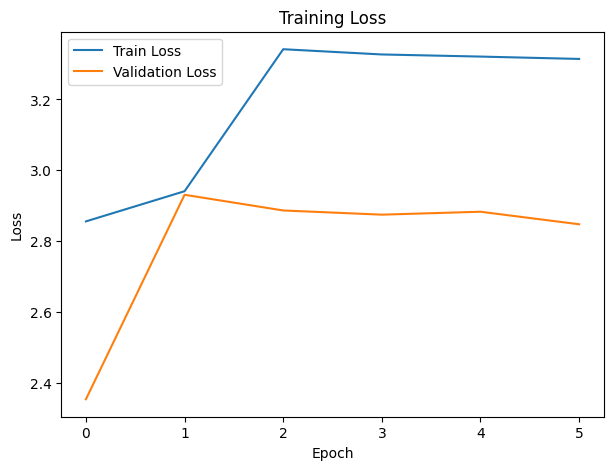

In [19]:
plt.figure(figsize=(7, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.show()


## 11. Save the trained mapper


In [ ]:
SAVE_PATH = f"{PROJECT_DIR}/outputs/clip_gpt2_prefix.pt"

torch.save({
    "prefix_mapper_state_dict": model.prefix_mapper.state_dict(),
    "prefix_length": PREFIX_LENGTH,
    "clip_model_name": CLIP_MODEL_NAME,
    "gpt2_model_name": GPT2_MODEL_NAME,
    "history": history
}, SAVE_PATH)

print("Saved to:", SAVE_PATH)


Saved to: /content/drive/MyDrive/clip-caption-project/outputs/clip_gpt2_prefix.pt


## 12. Caption generation function


In [24]:
@torch.no_grad()
def generate_caption(model, image, clip_processor, tokenizer, device, max_new_tokens=50):
    model.eval()

    if not isinstance(image, Image.Image):
        image = Image.open(image)
    image = image.convert("RGB")

    # --- CLIP image features ---
    pixel_values = clip_processor(images=image, return_tensors="pt")["pixel_values"].to(device)
    image_features = model.get_clip_image_features(pixel_values)

    # --- Prefix embeddings from mapper ---
    prefix_embeddings = model.prefix_mapper(image_features)
    prefix_embeddings = prefix_embeddings.view(1, model.prefix_length, model.gpt2_dim)

    # --- RAG: retrieve similar captions for this image ---
    vision_out = model.clip.vision_model(pixel_values=pixel_values)
    image_emb = model.clip.visual_projection(vision_out.pooler_output).squeeze(0).cpu()
    image_emb = image_emb / image_emb.norm().clamp(min=1e-8)
    retrieved = retrieve_similar(image_emb, k=3)
    retrieved_text = " | ".join(retrieved)

    # --- Build prompt (same format as training) ---
    prompt = (
        "You are an expert visual describer. "
        "Describe all objects, positions, and actions. "
        "Avoid generic phrases.\n"
        "Similar examples: " + retrieved_text + "\n"
        "Description:"
    )

    prompt_ids = tokenizer(prompt, return_tensors="pt")["input_ids"].to(device)
    prompt_embeddings = model.gpt2.transformer.wte(prompt_ids)  # (1, T, D)

    # --- Concatenate: [prefix | prompt] as input embeddings ---
    inputs_embeds = torch.cat([prefix_embeddings, prompt_embeddings], dim=1)  # (1, prefix+T, D)
    attention_mask = torch.ones(1, inputs_embeds.shape[1], device=device)

    # --- Generate ---
    generated_ids = model.gpt2.generate(
        inputs_embeds=inputs_embeds,
        attention_mask=attention_mask,
        max_new_tokens=max_new_tokens,
        num_beams=5,
        do_sample=False,
        no_repeat_ngram_size=3,
        repetition_penalty=1.25,
        length_penalty=0.9,
        early_stopping=True,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id
    )

    caption = tokenizer.decode(generated_ids[0], skip_special_tokens=True).strip()

    # --- Strip prompt echo if GPT2 repeats it ---
    marker = "Description:"
    if marker in caption:
        caption = caption.split(marker)[-1].strip()

    # --- Strip RAG leakage (retrieved examples separated by |) ---
    if "|" in caption:
        caption = caption.split("|")[0].strip()

    # --- Strip at newline ---
    if "\n" in caption:
        caption = caption.split("\n")[0].strip()

    # --- Strip at sentence boundary if too long (keep first 2 sentences) ---
    sentences = caption.replace("?", ".").replace("!", ".").split(".")
    sentences = [s.strip() for s in sentences if s.strip()]
    if len(sentences) > 2:
        caption = ". ".join(sentences[:2]) + "."

    return caption

## 13. Test generated captions on validation images


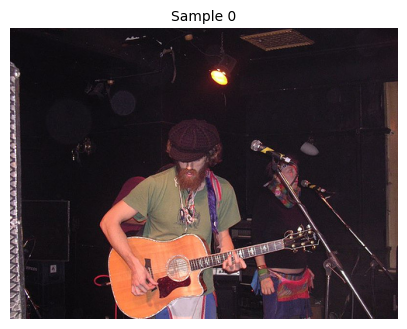

Generated caption:
A woman in

Real captions:
- A man in a brown hat and green t-shirt is playing the guitar with a band behind him .
- A man in a green shirt and black hat playing a guitar on stage .
- A man in a green shirt playing an acoustic guitar .
- A man playing the guitar on stage at a concert
- A gentleman playing guitar in a band .


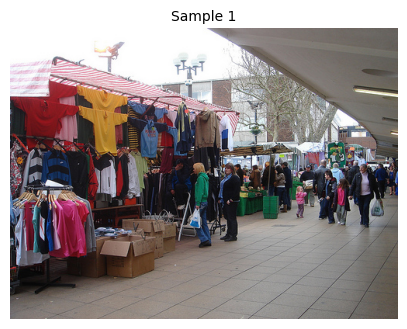

Generated caption:
An overhead view of an outdoor stand selling clothing and jewelry with two people looking at a stand and a person in an orange shirt kneeling down .

Real captions:
- Two women  one in a green jacket and another in a black jacket  are looking at shirts at an outside flea market .
- 2 friends are looking at clothes at a stand while at a shopping mall .
- There is a flea market with many shoppers during late fall or winter .
- People are shopping and browsing at outdoor vendors .
- people shop around an outdoor system of stores .


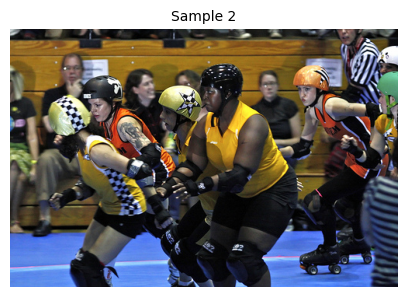

Generated caption:
A female skater dressed in shorts and a sleeveless t-shirt and wearing a safety helmet skates around a roller derby track as teammates observe the action in the background.

Real captions:
- Three girls in yellow jerseys and two girls in orange jerseys are competing in a Roller Derby event .
- Two teams of women in orange and yellow compete on rollerskates while a crowd watches .
- A group of spectators are watching woman playing in a roller derby .
- A group of women are participating in a roller derby game .
- A group of women rollerskating .


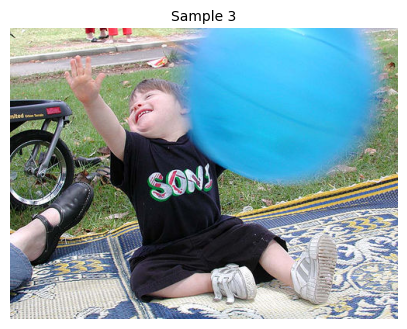

Generated caption:
A young man in a black shirt blows bubbles using a toy .

Real captions:
- Happy  smiley toddler sitting in a pretty blue  white and yellow blanket throwing a large blue ball .
- A little boy is playing with a ball while sitting on a rug that is on the grass .
- In this picture  a child is playing with a large blue ball .
- A small child smiles as a ball flies towards his face .
- A boy laughs as he is hit with a beach ball .


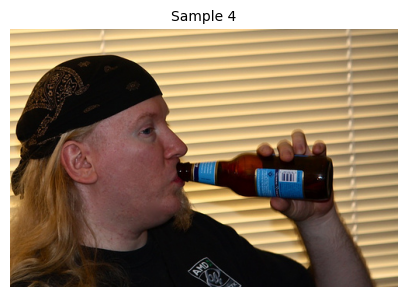

Generated caption:
A man is sitting down pointing and looking into the distance  there is beer bottles appearing in the background as well .

Real captions:
- A person with long  blond-hair wearing a bandanna drinks from a beer bottle while standing in front of window blinds .
- A white male with blond-hair is drinking beer .
- A man with long hair is drinking a beer .
- A man drinking out of a glass bottle .
- A man is drinking a beer .


In [28]:
START = 0    # change this to test different samples
NUM_SAMPLES = 5  # change this to test more

for i in range(START, START + NUM_SAMPLES):
    item = val_data[i]
    image = item["image"].convert("RGB")
    real_captions = item["caption"] if "caption" in item else item.get("captions", "")

    predicted_caption = generate_caption(
        model,
        image,
        clip_processor,
        gpt2_tokenizer,
        DEVICE
    )

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Sample {i}", fontsize=10)
    plt.show()

    print(f"Generated caption:")
    print(predicted_caption)

    print("\nReal captions:")
    if isinstance(real_captions, list):
        for cap in real_captions:
            print("-", cap)
    else:
        print("-", real_captions)

    print("=" * 80)

## 14. Test on your own image

Upload your image to:

```text
/content/drive/MyDrive/clip-caption-project/samples/test.jpg
```

Then run the next cell.


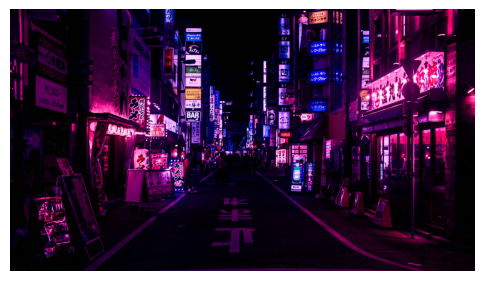

Generated caption: An Asian man walks down a street along side tall  narrow buildings of different colors .


In [31]:
test_image_path = f"{PROJECT_DIR}/samples/test.jpg"

if os.path.exists(test_image_path):
    image = Image.open(test_image_path).convert("RGB")

    caption = generate_caption(
        model,
        image,
        clip_processor,
        gpt2_tokenizer,
        DEVICE
    )

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    print("Generated caption:", caption)
else:
    print("No test image found.")
    print("Upload an image to:", test_image_path)


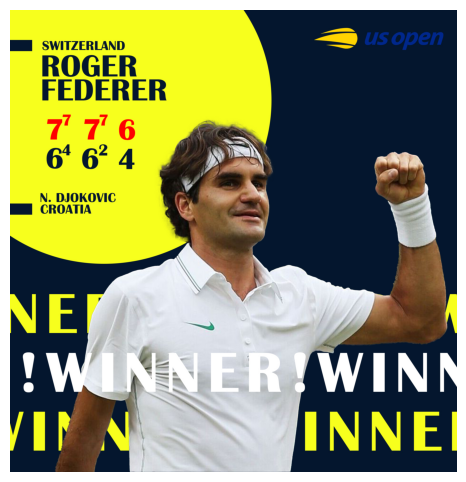

Generated caption: The tennis player receives the ball  and in doing so he backhanded the ball back towards his opponent .


In [32]:
test_image_path = f"{PROJECT_DIR}/samples/test.jpg"

if os.path.exists(test_image_path):
    image = Image.open(test_image_path).convert("RGB")

    caption = generate_caption(
        model,
        image,
        clip_processor,
        gpt2_tokenizer,
        DEVICE
    )

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    print("Generated caption:", caption)
else:
    print("No test image found.")
    print("Upload an image to:", test_image_path)


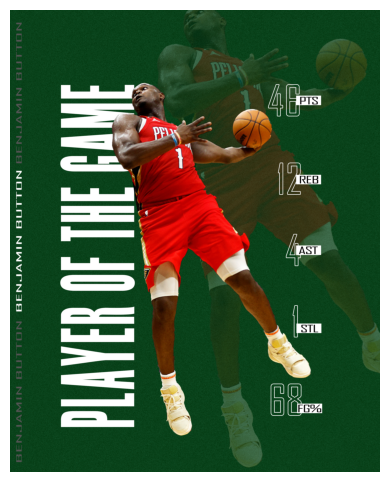

Generated caption: The basketball player in red is challenging the player in white for the ball .


In [33]:
test_image_path = f"{PROJECT_DIR}/samples/test.jpg"

if os.path.exists(test_image_path):
    image = Image.open(test_image_path).convert("RGB")

    caption = generate_caption(
        model,
        image,
        clip_processor,
        gpt2_tokenizer,
        DEVICE
    )

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    print("Generated caption:", caption)
else:
    print("No test image found.")
    print("Upload an image to:", test_image_path)


## 15. BLEU evaluation

BLEU is a simple automatic captioning metric. For your report, include BLEU-1 and BLEU-4.


In [29]:
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

nltk.download("punkt")

def simple_tokenize(text):
    return text.lower().strip().split()

@torch.no_grad()
def evaluate_bleu(model, val_data, num_samples=100):
    references = []
    hypotheses = []

    smoothie = SmoothingFunction().method4

    for i in tqdm(range(min(num_samples, len(val_data))), desc="BLEU Evaluation"):
        item = val_data[i]
        image = item["image"].convert("RGB")

        if "caption" in item:
            refs = item["caption"]
        elif "captions" in item:
            refs = item["captions"]
        else:
            refs = [item["sentence"]]

        if not isinstance(refs, list):
            refs = [str(refs)]

        pred = generate_caption(
            model,
            image,
            clip_processor,
            gpt2_tokenizer,
            DEVICE
        )

        references.append([simple_tokenize(r) for r in refs])
        hypotheses.append(simple_tokenize(pred))

    bleu1 = corpus_bleu(
        references,
        hypotheses,
        weights=(1, 0, 0, 0),
        smoothing_function=smoothie
    )

    bleu4 = corpus_bleu(
        references,
        hypotheses,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smoothie
    )

    return bleu1, bleu4


bleu1, bleu4 = evaluate_bleu(model, val_data, num_samples=100)

print("BLEU-1:", bleu1)
print("BLEU-4:", bleu4)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


BLEU Evaluation:   0%|          | 0/100 [00:00<?, ?it/s]

BLEU-1: 0.4451647757968666
BLEU-4: 0.06903742994143214


## 16. Save sample generated captions to a text file


In [ ]:
RESULTS_PATH = f"{PROJECT_DIR}/outputs/sample_captions.txt"

with open(RESULTS_PATH, "w", encoding="utf-8") as f:
    for i in range(20):
        item = val_data[i]
        image = item["image"].convert("RGB")

        refs = item["caption"] if "caption" in item else item.get("captions", "")

        pred = generate_caption(
            model,
            image,
            clip_processor,
            gpt2_tokenizer,
            DEVICE
        )

        f.write(f"Sample {i+1}\n")
        f.write(f"Generated: {pred}\n")
        f.write("References:\n")

        if isinstance(refs, list):
            for r in refs:
                f.write(f"- {r}\n")
        else:
            f.write(f"- {refs}\n")

        f.write("\n" + "=" * 80 + "\n\n")

print("Saved sample captions to:", RESULTS_PATH)


## 17. Optional: load a saved mapper later

Use this cell when you come back later and want to load the trained mapper without retraining.


In [ ]:
# Optional reload cell.
# Run this only after loading CLIP, GPT-2, defining ClipGPT2CaptionModel, and creating `model`.

LOAD_PATH = f"{PROJECT_DIR}/outputs/clip_gpt2_prefix.pt"

if os.path.exists(LOAD_PATH):
    checkpoint = torch.load(LOAD_PATH, map_location=DEVICE)
    model.prefix_mapper.load_state_dict(checkpoint["prefix_mapper_state_dict"])
    model.to(DEVICE)
    model.eval()
    print("Loaded mapper from:", LOAD_PATH)
else:
    print("No saved mapper found at:", LOAD_PATH)


# Report notes

Use these points in your final report:

## Methodology

- CLIP image encoder extracts visual embeddings from each image.
- A trainable prefix mapper converts CLIP image embeddings into GPT-2-compatible prefix embeddings.
- GPT-2 receives the learned image prefix and generates captions.
- CLIP and GPT-2 are frozen.
- Only the mapper is trained.

## Evaluation

- Training loss
- Validation loss
- BLEU-1
- BLEU-4
- Human comparison of generated and reference captions

## Limitations

- Captions may be generic.
- The model uses a global CLIP embedding, so it may miss small objects.
- GPT-2 was not originally trained as an image-captioning model.
- Small training subsets reduce caption quality.

## Future work

- Train on more Flickr30k samples.
- Try MS-COCO.
- Fine-tune part of GPT-2.
- Compare with BLIP.
- Add CIDEr evaluation.
